# Calculate treatment and outcome

Store all of the causal effects between variables in one grid dataframe.

## Code setup

In [109]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from dowhy import CausalModel
from castle.algorithms import PC
from castle.common import GraphDAG

## Generate some data

In [110]:
df_data=pd.read_csv("generated_dependant_data.csv")

In [111]:
#y = pd.get_dummies(df_data['Stroke team']).astype(int)
# Make new column for each stroke team:
#df_data = pd.concat((df_data, pd.get_dummies(df_data['Stroke team']).astype(int)), axis=1)
# Remove the original stroke team column:
#df_data = df_data.drop('Stroke team', axis='columns')

In [112]:
original_features = list(df_data.columns)
features = original_features + ['thrombolysis', 'discharge_disability']

In [113]:
df_data

,Onset_during_sleep,Precise_onset_known,AF_patients,AF_patients_on_anticoagulants,Patient age,Disabilities (0-5),Stroke team,Arrival to scan time,Stroke severity
0,0,0,0,1,52.5,0,64,56,5.0
1,0,1,0,1,77.5,1,42,35,25.0
2,0,1,0,1,62.5,0,12,22,13.0
3,0,1,0,0,72.5,0,5,129,9.0
4,0,1,0,1,62.5,0,79,579,3.0
...,...,...,...,...,...,...,...,...,...
995,0,1,0,0,72.5,0,87,3,2.0
996,0,1,0,1,57.5,0,73,5,23.0
997,0,1,0,1,77.5,3,10,156,3.0
998,0,0,0,1,37.5,0,42,35,25.0


In [114]:
n_patients=len(df_data)

## Make empty effect dataframe

Make an empty dataframe with row and column names for all of our features plus the treatment and outcome:

In [115]:
df_effects = pd.DataFrame(columns=features, index=features, dtype=float)
# Fill missing data with zeros:
df_effects = df_effects.fillna(0.0)

The dataframe should have all of the correct column and row names, and all of the values should be zero:

In [116]:
df_effects.head()

,Onset_during_sleep,Precise_onset_known,AF_patients,AF_patients_on_anticoagulants,Patient age,Disabilities (0-5),Stroke team,Arrival to scan time,Stroke severity,thrombolysis,discharge_disability
Onset_during_sleep,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Precise_onset_known,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AF_patients,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AF_patients_on_anticoagulants,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Patient age,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Update some values

Make the causal effect go from each row name to each column name.

For example, to update the effect of onset during sleep on precise onset known:

In [117]:
def z (a=-1,b=1):
    """Helps assign a random value to define the relationship between various variables"""
    return (b - a) * np.random.random_sample() + a

In [118]:
df_effects.loc['Onset_during_sleep', 'Precise_onset_known']= z()
df_effects.loc['Onset_during_sleep', 'thrombolysis']= z()
df_effects.loc['Precise_onset_known', 'thrombolysis']= z()
df_effects.loc['AF_patients', 'AF_patients_on_anticoagulants']= z()
df_effects.loc['AF_patients_on_anticoagulants', 'thrombolysis']= z()
df_effects.loc['AF_patients','discharge_disability']= z()
df_effects.loc['Patient age','Disabilities (0-5)']= z()
df_effects.loc['Patient age','thrombolysis']= z()
df_effects.loc['Patient age','discharge_disability']= z()
df_effects.loc['Disabilities (0-5)','thrombolysis']= z()
df_effects.loc['Disabilities (0-5)','discharge_disability']= z()
df_effects.loc['Arrival to scan time','thrombolysis']= z()
df_effects.loc['Stroke severity','thrombolysis']= z()
df_effects.loc['Stroke severity','discharge_disability']= z()
df_effects.loc['thrombolysis','discharge_disability']= z()

In [119]:
for x in y.columns:
    df_effects.loc[x,'Arrival to scan time']=np.random.random_sample()
    df_effects.loc[x,'thrombolysis']=np.random.random_sample()
    df_effects.loc[x,'discharge_disability']=np.random.random_sample()
    x

Check that this updated in the dataframe:

In [120]:
df_effects.head()

,Onset_during_sleep,Precise_onset_known,AF_patients,AF_patients_on_anticoagulants,Patient age,Disabilities (0-5),Stroke team,Arrival to scan time,Stroke severity,thrombolysis,discharge_disability
Onset_during_sleep,0.0,0.889937,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.907154,0.000000
Precise_onset_known,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,-0.506705,0.000000
AF_patients,0.0,0.000000,0.0,0.242997,0.0,0.000000,0.0,0.0,0.0,0.000000,0.669310
AF_patients_on_anticoagulants,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.223715,0.000000
Patient age,0.0,0.000000,0.0,0.000000,0.0,0.568401,0.0,0.0,0.0,0.421012,0.960358


## Calculate treatment values

First generate some random noise:

In [121]:
noise_t = np.random.normal(0, 0.1, n_patients)

Use a linear combination of this noise and the features to calculate a value for treatment for each patient.

In [122]:
# Calculate data by combining these generated data and causal effects.
# Treatment:
t = np.sum((
    [noise_t] +
    [df_data[col] * df_effects.loc[col, 'thrombolysis'] for col in df_data.columns]
), axis=0)

Check the first few treatment values:

In [123]:
t[:5]

array([ 55.234,  42.865,  33.965, 106.993, 388.263])

## Convert treatment values to binary

Use a conversion function to decide whether each person is treated based on their score. People with higher scores are more likely (but not guaranteed) to be treated.

Use these functions from the DoWhy package:

In [124]:
# Functions for converting treatment calculation to binary decision.

import math

# Functions from dowhy `datasets` module:
# https://www.pywhy.org/dowhy/v0.14/_modules/dowhy/datasets.html#linear_dataset

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def convert_to_binary(x, stochastic=True):
    p = sigmoid(x)
    if stochastic:
        return np.random.choice([0, 1], 1, p=[1 - p, p])
    else:
        return int(p > 0.5)

Run the conversion function:

In [125]:
# Convert treatment to binary:
t_bin = np.array([convert_to_binary(x) for x in t]).flatten()

Check the first few results:

In [126]:
t_bin[:5]

array([1, 1, 1, 1, 1])

Put this with the rest of the data:

In [127]:
df_data['thrombolysis'] = t_bin

In [128]:
df_data

,Onset_during_sleep,Precise_onset_known,AF_patients,AF_patients_on_anticoagulants,Patient age,Disabilities (0-5),Stroke team,Arrival to scan time,Stroke severity,thrombolysis
0,0,0,0,1,52.5,0,64,56,5.0,1
1,0,1,0,1,77.5,1,42,35,25.0,1
2,0,1,0,1,62.5,0,12,22,13.0,1
3,0,1,0,0,72.5,0,5,129,9.0,1
4,0,1,0,1,62.5,0,79,579,3.0,1
...,...,...,...,...,...,...,...,...,...,...
995,0,1,0,0,72.5,0,87,3,2.0,1
996,0,1,0,1,57.5,0,73,5,23.0,1
997,0,1,0,1,77.5,3,10,156,3.0,1
998,0,0,0,1,37.5,0,42,35,25.0,1


Calculate outcome values

Note: Ideally the outcomes would be on a MRS Scale but for now we will assume 0 is a bad outcome and 1 is a good outcome

In [129]:
noise_out = np.random.normal(0, 0.1, n_patients)

In [130]:
out = np.sum((
    [noise_out] +
    [df_data[col] * df_effects.loc[col, 'discharge_disability'] for col in df_data.columns]
), axis=0)

In [131]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def convert_to_binary(x, stochastic=True):
    p = sigmoid(x)
    if stochastic:
        return np.random.choice([0, 1], 1, p=[1 - p, p])
    else:
        return int(p > 0.5)

In [132]:
out_bin = np.array([convert_to_binary(x) for x in out]).flatten()

In [133]:
df_data['discharge_disability'] = out_bin

In [134]:
df_data

,Onset_during_sleep,Precise_onset_known,AF_patients,AF_patients_on_anticoagulants,Patient age,Disabilities (0-5),Stroke team,Arrival to scan time,Stroke severity,thrombolysis,discharge_disability
0,0,0,0,1,52.5,0,64,56,5.0,1,1
1,0,1,0,1,77.5,1,42,35,25.0,1,1
2,0,1,0,1,62.5,0,12,22,13.0,1,1
3,0,1,0,0,72.5,0,5,129,9.0,1,1
4,0,1,0,1,62.5,0,79,579,3.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
995,0,1,0,0,72.5,0,87,3,2.0,1,1
996,0,1,0,1,57.5,0,73,5,23.0,1,1
997,0,1,0,1,77.5,3,10,156,3.0,1,1
998,0,0,0,1,37.5,0,42,35,25.0,1,1


In [135]:
df_data.to_csv("generated_data_final.csv", index=False)

Making a DAG

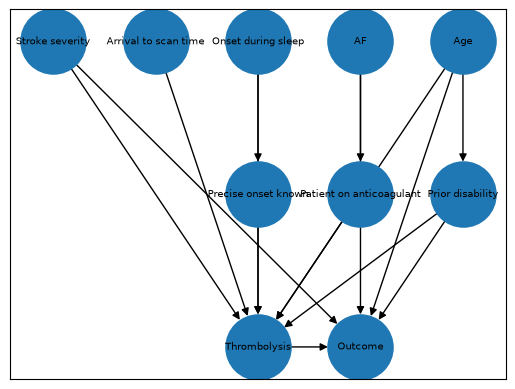

In [137]:
adj_matrix= np.array([
    [0, 1, 0, 0, 0, 0, 0, 0, 1 ,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1 ,0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0 ,1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1 ,0],
    [0, 0, 0, 0, 0, 1, 0, 0, 1 ,1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1 ,1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1 ,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1 ,1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0 ,1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0 ,0],

])

node_names=["Onset during sleep","Precise onset known","AF","Patient on anticoagulant","Age","Prior disability","Arrival to scan time","Stroke severity","Thrombolysis","Outcome"]

G=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

mapping={i:node_names[i] for i in range(len(node_names))}
G=nx.relabel_nodes(G, mapping)

pos={
    "Onset during sleep":(3,2),
    "Precise onset known":(3,1),
    "AF":(4,2),
    "Patient on anticoagulant":(4,1),
    "Age":(5,2),
    "Prior disability":(5,1),
    "Arrival to scan time":(2,2),
    "Stroke severity":(1,2),
    "Thrombolysis":(3,0),
    "Outcome":(4,0)
}

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    arrows=True,
    node_size=2200,
    font_size=7,
    arrowsize=11
)

plt.savefig("real_causal.png")